### We will try different methods to classify after court document.
### Lets first try to train binary classification model for PFUB Erlass Document

In [1]:
import os
from ast import literal_eval
import pandas as pd
import spacy
import re
from spacy.tokenizer import Tokenizer
import matplotlib.pyplot as plt
import dill
import numpy as np

In [2]:
data = pd.read_csv('../data/PFUB_ERLASS_dataset_processed_with_geschaeftsnummer.csv')

In [6]:
print(data.iloc[25]['text'])

Amtsgericht Leverkusen
-45- Amtsgericht Leverkusen, Gerichtsstr. 9, 51379 Leverkusen-
09.07.2023
Opladen
Seite 1 von 1
Aktenzeichen
Pair Finance GmbH
PAIR Finance GmbH
45 M 2835/23
Hardenbergstraße 32
bei Antwort bitte angeben
10623 Berlin
31. Juli 2023
Bearbeiter
AZ
Frau Weigel
Durchwahl
02171/491--321
Ihr Zeichen: 122229123668
Sehr geehrte Damen und Herren,
in der Zwangsvollstreckungssache
Liquandum Capital GmbH gegen Gashi
wurde Ihrem Antrag auf Erlass eine Pfändungs- und
Überweisungsbeschlusses entsprochen. Die Zustellung des
Pfändungs- und Überweisungsbeschlusses an den / die
Anschrift
Drittschuldner und an die Schuldnerseite wurde vermittelt. Anbei
Gerichtsstr. 9
51379 Leverkusen-Opladen
erhalten Sie die mit Ihrem Antrag eingereichten
Sprechzeiten
Mo bis Fr 07:30 bis 16:00 Uhr;
Vollstreckungsunterlagen zurück.
persönliche Vorsprache nach
Terminvereinbarung
Mit freundlichen Grüßen
Telefon
Weigel
02171/491-0
Telefax:
Justizbeschäftigte
02171/491699
automatisiert erstellt, ohne Unte

In [3]:
data['document_type'].value_counts()

document_type
ladung_va                                 2101
mail_attachments                          1006
monierung_mb                               545
attachment_and_transfer_order              539
approved_seizure                           408
court_inbox                                346
approved_attachment_and_transfer_order      60
enforcement_order                           23
contradiction                                3
Name: count, dtype: int64

In [4]:
data['is_pfub'].value_counts()

is_pfub
False    4563
True      468
Name: count, dtype: int64

In [5]:
import os

notebook_dir = os.getcwd()
project_dir = os.path.dirname(os.path.dirname(os.path.dirname(notebook_dir)))
print("Notebook Directory:", notebook_dir)
print("Project Directory:", project_dir)
os.chdir(project_dir)

Notebook Directory: /Users/melih.gorgulu/Desktop/Projects/intent_recognition/notebooks/after-court/pfub-erlass
Project Directory: /Users/melih.gorgulu/Desktop/Projects/intent_recognition


In [6]:

X_text = data['text_w_tags']
y = data['is_pfub']

# train test split
from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set size: {len(X_train_text)}, Test set size: {len(X_test_text)}")
print(f"Train set is pfub dist: {y_train.value_counts(normalize=True)}")
print(f"Test set is pfub dist: {y_test.value_counts(normalize=True)}")


Train set size: 4024, Test set size: 1007
Train set is pfub dist: is_pfub
False    0.907058
True     0.092942
Name: proportion, dtype: float64
Test set is pfub dist: is_pfub
False    0.906653
True     0.093347
Name: proportion, dtype: float64


In [7]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
import pickle
from sklearn.feature_extraction.text import TfidfVectorizer
# Make sure to import ClassificationSpacyLemmaTokenizer from the source code.
from src.services.models.aftercourt_tokenizer import ClassificationSpacyLemmaTokenizer

In [9]:
vec_path = "/Users/melih.gorgulu/Desktop/Projects/intent_recognition/notebooks/after-court/models/vectorizers/05-12-2026_tf_idf_vectorizer_v1.dill"
tf_idf_vectorizer = dill.load(open(vec_path, 'rb'))

In [ ]:
X_train_tfidf = tf_idf_vectorizer.transform(X_train_text)
X_test_tfidf = tf_idf_vectorizer.transform(X_test_text)

rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train_tfidf, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
y_pred = rf_classifier.predict(X_test_tfidf)

In [14]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)


print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

"""
    true negatives is :math:`C_{0,0}`, false negatives is :math:`C_{1,0}`, 
    true positives is :math:`C_{1,1}` and false positives is :math:`C_{0,1}
"""

Accuracy: 0.9980

Classification Report:
              precision    recall  f1-score   support

       False       1.00      1.00      1.00       913
        True       0.98      1.00      0.99        94

    accuracy                           1.00      1007
   macro avg       0.99      1.00      0.99      1007
weighted avg       1.00      1.00      1.00      1007


Confusion Matrix:
[[911   2]
 [  0  94]]


'\n    true negatives is :math:`C_{0,0}`, false negatives is :math:`C_{1,0}`, \n    true positives is :math:`C_{1,1}` and false positives is :math:`C_{0,1}\n'

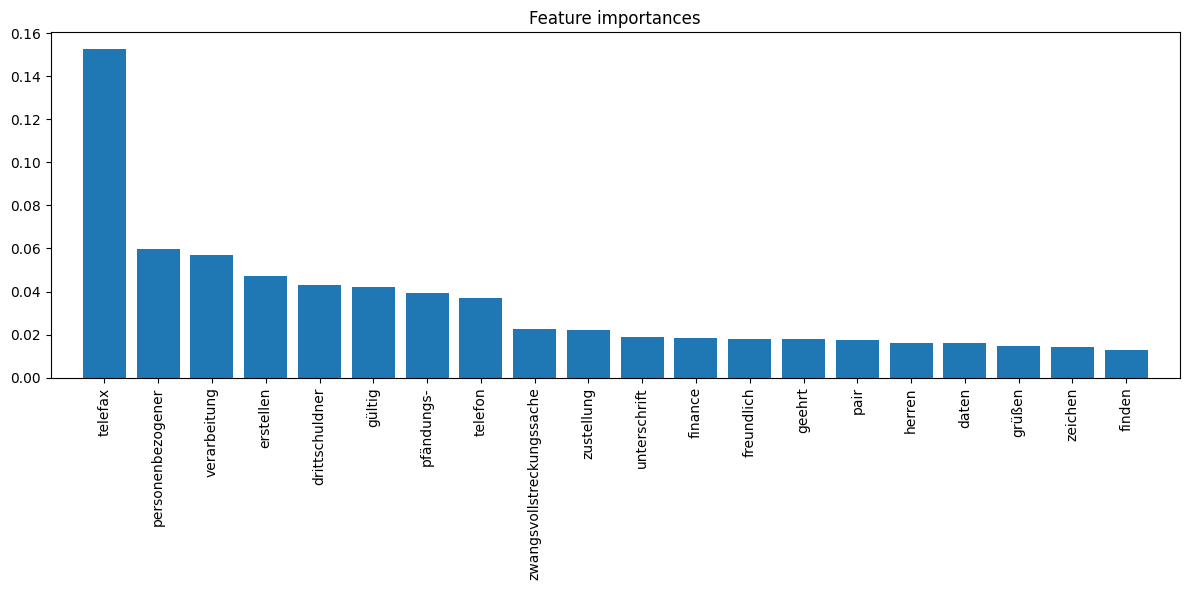

In [15]:
# plot feature importance of the random forest classifier
feature_names = tf_idf_vectorizer.get_feature_names_out()
importances = rf_classifier.feature_importances_
indices = np.argsort(importances)[::-1]
# Plot the feature importances of the forest
plt.figure(figsize=(12, 6))
plt.title("Feature importances")
plt.bar(range(20), importances[indices][:20], align="center")
plt.xticks(range(20), [feature_names[i] for i in indices][:20], rotation=90)
plt.xlim([-1, 20])
plt.tight_layout()
plt.show()

In [16]:
indices = np.argsort(importances)[::-1]
feature_names = tf_idf_vectorizer.get_feature_names_out()
print(feature_names[indices][:100])

['telefax' 'personenbezogener' 'verarbeitung' 'erstellen' 'drittschuldner'
 'gültig' 'pfändungs-' 'telefon' 'zwangsvollstreckungssache' 'zustellung'
 'unterschrift' 'finance' 'freundlich' 'geehrt' 'pair' 'herren' 'daten'
 'grüßen' 'zeichen' 'finden' 'damen' 'antrag' 'anschrift' 'antwort'
 'dr_reference' 'hardenbergstr' 'amtsgericht' 'justiz' 'bitte' 'beschluss'
 'schutz' '<' 'bic' 'capital' 'seite' '<url>' 'übersenden' 'b' 'hinweis'
 'wunsch' 'abs' 'termin' '>' 'berlin' 'erhalten' '<email>' 'gmbh'
 'artikel' 'angeben' 'liquandum' 'stets' 'abgabe' 'vermögensauskunft'
 '<number>-<phone><number>-<number>' 'forderung' '850e' 'eur'
 'information' '<number>,' 'höhe' 'zahlung' 'dienstkonto' 'vollständig'
 'number' 'bestimmen' '<phone>' 'bankverbindung' 'gegen'
 '<number>:<number>' 'iban' 'frist' 'rdg' 'gesetzlich' 'nachricht' 'frau'
 'soweit' 'zugang' 'str' '<number>-<number>' 'obig' 'fall' 'datum'
 'papierform' 'gruß' 'gerichtsvollzieher' '<date>' 'hardenbergstraße'
 'schreiben' 'geschäftsnu

In [ ]:
# TODO:
# 1) Seperate (TF-IDF+Tokenizer) and ML Model in Pipeline
# 2) Try out methods: One Multi class, One vs All Multi class with your own models, One vs All Multi class with sklearn
# 3) Compare them

In [17]:
fp_mask = (y_test == 0) & (y_pred == 1)
fp_idx = X_test_text[fp_mask].index
fp_data = data[data.index.isin(fp_idx)]
fp_data
# ASK THIS

,text,object_key,document_type,cleaned_text,data,is_pfub,is_ladung,tokenized,text_w_tags
3260,Amtsgericht Langen (Hessen)\nVollstreckungsger...,25.10.2024/ocr-v2_EU_Z_00021FreitextschreibenB...,court_inbox,amtsgericht langen (hessen)\nvollstreckungsger...,NaN,False,False,"['amtsgericht', 'lang', 'hessen', 'vollstrecku...",amtsgericht langen (hessen)\nvollstreckungsger...
3705,Amtsgericht Rostock\nAmtsgericht Rostock PF 10...,28.10.2024/ocr-v2_RB_004_28102024_133353.pdf,court_inbox,amtsgericht rostock\namtsgericht rostock pf 10...,NaN,False,False,"['amtsgericht', 'rostock', 'amtsgericht', 'ros...",amtsgericht rostock\namtsgericht rostock pf <N...


In [18]:
def print_out_clickable_link(df):
    for index, row in df.iterrows():
        print(f"Index: {index}, Link: https://eu-central-1.console.aws.amazon.com/s3/object/pair-scanner?region=eu-central-1&prefix={row['object_key']}")

In [19]:
print_out_clickable_link(fp_data)

Index: 3260, Link: https://eu-central-1.console.aws.amazon.com/s3/object/pair-scanner?region=eu-central-1&prefix=25.10.2024/ocr-v2_EU_Z_00021FreitextschreibenBenutzer_1A8DF6D6-FF66-4C71-B80A-EF79228BC123.pdf
Index: 3705, Link: https://eu-central-1.console.aws.amazon.com/s3/object/pair-scanner?region=eu-central-1&prefix=28.10.2024/ocr-v2_RB_004_28102024_133353.pdf


In [20]:
fn_mask = (y_test == 1) & (y_pred == 0)
fn_idx = X_test_text[fn_mask].index
fn_data = data[data.index.isin(fn_idx)]
fn_data
# ASK THIS

,text,object_key,document_type,cleaned_text,data,is_pfub,is_ladung,tokenized,text_w_tags


In [23]:
notebook_dir = "/Users/melih.gorgulu/Desktop/Projects/intent_recognition/notebooks"

In [24]:
# save the trained model
save_path = os.path.join(notebook_dir, "after-court/models/classification/12-01-2026_binary_pfub_rf_classifier_v1.dill")
with open(save_path, "wb") as f:
    dill.dump(rf_classifier, f)